In [42]:
# ============================================================
# STEP 2.1 — Imports & Configuration  (VS Code version)
# ============================================================

import os
import pandas as pd
import numpy as np
from scipy import stats

# ---------- CONFIG ----------
# Path to your CSV file (relative to notebook or absolute)
csv_path = "./data_sets/student_mental_health_dataset.csv"

# Column containing timestamps (set manually if known)
timestamp_col = None  # e.g., "timestamp"

# Cleaning parameters
aggregate_duplicates = True
dup_agg_func = "mean"
impute_short_gaps = True
short_gap_threshold = 3
impute_method = "linear"
flag_long_gaps = True
long_gap_keep = True
outlier_method = "zscore"  # "zscore" or "rolling_median"
zscore_thresh = 3.5
rolling_median_window = 11
outlier_action = "flag"  # "flag", "clip", "drop"

# Save path for cleaned data
save_clean_path = "data_sets\cleaned_snapshot.parquet"
os.makedirs(os.path.dirname(save_clean_path), exist_ok=True)


In [44]:
# ============================================================
# STEP 2.2 — Load dataset & detect timestamp column
# ============================================================

if not os.path.exists(csv_path):
    raise FileNotFoundError(f" CSV not found at: {csv_path}")

df = pd.read_csv(csv_path)
print(f" Loaded dataset — shape: {df.shape}")

# Detect timestamp column
if timestamp_col is None:
    candidates = [c for c in df.columns if c.lower() in ("timestamp", "datetime", "date", "time")]
    if not candidates:
        raise ValueError("Could not auto-detect a timestamp column. Please set 'timestamp_col' manually.")
    timestamp_col = candidates[0]

print(f" Using timestamp column: {timestamp_col}")

# Convert to datetime
df[timestamp_col] = pd.to_datetime(df[timestamp_col], errors="coerce")
null_ts = df[timestamp_col].isna().sum()
if null_ts:
    print(f" Dropping {null_ts} rows with invalid timestamps.")
    df = df.dropna(subset=[timestamp_col])


 Loaded dataset — shape: (2373, 13)
 Using timestamp column: Timestamp


In [45]:
# ============================================================
# STEP 2.3 — Sort, set index & handle duplicates
# ============================================================

df = df.sort_values(by=timestamp_col).reset_index(drop=True)
df = df.set_index(timestamp_col)
df.index.name = "timestamp"

dup_count = df.index.duplicated().sum()
if dup_count > 0:
    print(f"Found {dup_count} duplicate timestamps.")
    if aggregate_duplicates:
        numeric_cols = df.select_dtypes(include=[np.number]).columns
        df = df.groupby(df.index).agg({col: dup_agg_func for col in numeric_cols})
        print("Aggregated duplicate timestamps.")
    else:
        df = df[~df.index.duplicated(keep="first")]
        print("Dropped duplicate timestamps.")


In [46]:
# ============================================================
# STEP 2.4 — Infer frequency & detect missing timestamps
# ============================================================

try:
    inferred_freq = pd.infer_freq(df.index)
except Exception:
    inferred_freq = None

if inferred_freq is None:
    diffs = df.index.to_series().diff().dropna()
    median_diff = diffs.median()
    inferred_freq = pd.tseries.frequencies.to_offset(median_diff).freqstr

print(f"Inferred frequency: {inferred_freq}")

# Build full index to detect missing timestamps
full_index = pd.date_range(df.index.min(), df.index.max(), freq=inferred_freq)
missing_ts = full_index.difference(df.index)
print(f"Missing timestamps: {len(missing_ts)} ({len(missing_ts)/len(full_index):.2%})")


Inferred frequency: D
Missing timestamps: 0 (0.00%)


In [47]:
# ============================================================
# STEP 2.5 — Handle short & long gaps
# ============================================================

df = df.reindex(full_index)
df.index.name = "timestamp"

if impute_short_gaps:
    if impute_method == "linear":
        df = df.interpolate(method="time", limit=short_gap_threshold, limit_direction="both")
    elif impute_method in ["ffill", "bfill"]:
        df = df.fillna(method=impute_method, limit=short_gap_threshold)
    print(f"Short gaps filled using '{impute_method}' method.")

if flag_long_gaps:
    df["in_long_gap"] = df.isnull().any(axis=1)
    long_gap_count = df["in_long_gap"].sum()
    print(f"Flagged {long_gap_count} timestamps in long gaps.")
    if not long_gap_keep:
        df = df[~df["in_long_gap"]]
        print("🧹 Dropped long-gap rows.")


Short gaps filled using 'linear' method.
Flagged 0 timestamps in long gaps.


C:\Users\ASUS\AppData\Local\Temp\ipykernel_7332\3648780564.py:10: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df = df.interpolate(method="time", limit=short_gap_threshold, limit_direction="both")


In [48]:
# ============================================================
# STEP 2.6 — Outlier detection & handling
# ============================================================

numeric_cols = df.select_dtypes(include=[np.number]).columns

if outlier_method == "zscore":
    for col in numeric_cols:
        z = np.abs(stats.zscore(df[col].dropna()))
        df["is_outlier_" + col] = False
        df.loc[df[col].notna(), "is_outlier_" + col] = z > zscore_thresh

elif outlier_method == "rolling_median":
    for col in numeric_cols:
        med = df[col].rolling(rolling_median_window, center=True).median()
        mad = (df[col] - med).abs().rolling(rolling_median_window, center=True).median()
        df["is_outlier_" + col] = (df[col] - med).abs() > (zscore_thresh * mad)

# Combine all flags
outlier_flags = [c for c in df.columns if c.startswith("is_outlier_")]
df["is_outlier_any"] = df[outlier_flags].any(axis=1)
print(f"Outliers flagged: {df['is_outlier_any'].sum()} rows")

# Optional outlier handling
if outlier_action == "clip":
    for col in numeric_cols:
        mu, sigma = df[col].mean(), df[col].std()
        df[col] = df[col].clip(mu - zscore_thresh*sigma, mu + zscore_thresh*sigma)
elif outlier_action == "drop":
    before = df.shape[0]
    df = df[~df["is_outlier_any"]]
    print(f"🧹 Dropped {before - df.shape[0]} outlier rows.")


Outliers flagged: 0 rows


In [49]:
df

,Heart_Rate,Blood_Pressure_Systolic,Blood_Pressure_Diastolic,Respiration_Rate,Sleep_Duration,Activity_Levels,Mood,Cognitive_Load,Study_Hours,Academic_Stressors,...,is_outlier_Heart_Rate,is_outlier_Blood_Pressure_Systolic,is_outlier_Blood_Pressure_Diastolic,is_outlier_Respiration_Rate,is_outlier_Sleep_Duration,is_outlier_Activity_Levels,is_outlier_Cognitive_Load,is_outlier_Study_Hours,is_outlier_Academic_Stressors,is_outlier_any
timestamp,,,,,,,,,,,,,,,,,,,,,
2019-01-01,84,120,77,18,6,5466,Happy,8,10,8,...,False,False,False,False,False,False,False,False,False,False
2019-01-02,100,131,91,23,5,7311,Neutral,6,9,6,...,False,False,False,False,False,False,False,False,False,False
2019-01-03,96,156,89,29,6,2189,Happy,7,8,8,...,False,False,False,False,False,False,False,False,False,False
2019-01-04,82,134,98,24,4,4888,Happy,9,6,8,...,False,False,False,False,False,False,False,False,False,False
2019-01-05,71,129,84,17,6,7556,Neutral,8,11,5,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-26,90,157,88,21,4,6773,Neutral,6,8,5,...,False,False,False,False,False,False,False,False,False,False
2025-06-27,73,118,72,14,8,11816,Happy,6,10,9,...,False,False,False,False,False,False,False,False,False,False
2025-06-28,108,137,87,23,6,5410,Anxious,8,9,6,...,False,False,False,False,False,False,False,False,False,False


In [8]:
%pip install pyarrow


You should consider upgrading via the 'c:\Users\ASUS\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.


In [50]:
# 1. Convert Period dtypes (columns + index) to safe types, then try to to_parquet()
import pandas as pd
import numpy as np
import os
import importlib

save_parquet_path = "./data/cleaned_snapshot_backup.parquet"
os.makedirs(os.path.dirname(save_parquet_path), exist_ok=True)

# 1.a Detect Period-typed columns
period_cols = [c for c in df.columns if pd.api.types.is_period_dtype(df[c].dtype)]
print("Period-typed columns:", period_cols)

# Convert Period columns to timestamps (best for time info) or strings if not time-like
for c in period_cols:
    try:
        # Try to convert to timestamp if Period has freq
        df[c] = df[c].dt.to_timestamp()
        print(f"Converted column {c} to timestamp via .dt.to_timestamp()")
    except Exception:
        # fallback to string
        df[c] = df[c].astype(str)
        print(f"Converted column {c} to string (fallback)")

# 1.b Detect PeriodIndex
if isinstance(df.index, pd.PeriodIndex):
    try:
        df.index = df.index.to_timestamp()
        df.index.name = "timestamp"
        print("Converted PeriodIndex to Timestamp index.")
    except Exception as e:
        print("Could not convert PeriodIndex to Timestamp:", e)
        # As fallback convert to string index (not ideal for time series ops)
        df.index = df.index.astype(str)
        print("Converted PeriodIndex to string index (fallback).")

# 1.c Convert any pandas ExtensionDtype columns that may not be supported (example: Arrow extension)
# Convert any 'object' columns that are actually pandas extension arrays to strings
for c in df.columns:
    if pd.api.types.is_extension_array_dtype(df[c].dtype):
        # convert to a native numpy dtype if possible, else to string
        try:
            df[c] = np.asarray(df[c])
            print(f"Converted extension array column {c} to numpy array.")
        except Exception:
            df[c] = df[c].astype(str)
            print(f"Converted extension array column {c} to str fallback.")

# 1.d Try to save parquet (use available engine if present)
def available_parquet_engine():
    if importlib.util.find_spec("pyarrow"):
        return "pyarrow"
    if importlib.util.find_spec("fastparquet"):
        return "fastparquet"
    return None

engine = available_parquet_engine()
if engine:
    try:
        df.to_parquet(save_parquet_path, engine=engine)
        print("Saved parquet using engine:", engine)
    except Exception as e:
        print("Parquet save failed even after converting types. Error:", repr(e))
        engine = None
else:
    print("No parquet engine detected in environment.")

# 1.e Fallback: save CSV if parquet not available or still failed
if engine is None:
    backup_csv = "./data/cleaned_snapshot_backup.csv.gz"
    df.to_csv(backup_csv, index=True, compression="gzip")
    print("Saved gzipped CSV to:", backup_csv)


Period-typed columns: []
Saved parquet using engine: pyarrow


C:\Users\ASUS\AppData\Local\Temp\ipykernel_7332\3579513747.py:11: DeprecationWarning: is_period_dtype is deprecated and will be removed in a future version. Use `isinstance(dtype, pd.PeriodDtype)` instead
  period_cols = [c for c in df.columns if pd.api.types.is_period_dtype(df[c].dtype)]


In [51]:
# Per-column outlier counts
outlier_flags = [c for c in df.columns if c.startswith("is_outlier_")]
per_col_counts = {c: df[c].sum() for c in outlier_flags}
print("Per-column outlier counts:")
for k, v in per_col_counts.items():
    print(f"  {k}: {int(v)}")

# Rows where any outlier flag is True
outlier_rows = df[df["is_outlier_any"]].copy()
print("\nSample of outlier rows (first 10):")
display(outlier_rows.head(10))

# Show timestamps of outliers
print("\nTimestamps of outliers:")
print(outlier_rows.index.to_series().dt.strftime("%Y-%m-%d %H:%M:%S").tolist())


Per-column outlier counts:
  is_outlier_Heart_Rate: 0
  is_outlier_Blood_Pressure_Systolic: 0
  is_outlier_Blood_Pressure_Diastolic: 0
  is_outlier_Respiration_Rate: 0
  is_outlier_Sleep_Duration: 0
  is_outlier_Activity_Levels: 0
  is_outlier_Cognitive_Load: 0
  is_outlier_Study_Hours: 0
  is_outlier_Academic_Stressors: 0
  is_outlier_any: 0

Sample of outlier rows (first 10):


,Heart_Rate,Blood_Pressure_Systolic,Blood_Pressure_Diastolic,Respiration_Rate,Sleep_Duration,Activity_Levels,Mood,Cognitive_Load,Study_Hours,Academic_Stressors,...,is_outlier_Heart_Rate,is_outlier_Blood_Pressure_Systolic,is_outlier_Blood_Pressure_Diastolic,is_outlier_Respiration_Rate,is_outlier_Sleep_Duration,is_outlier_Activity_Levels,is_outlier_Cognitive_Load,is_outlier_Study_Hours,is_outlier_Academic_Stressors,is_outlier_any
timestamp,,,,,,,,,,,,,,,,,,,,,



Timestamps of outliers:
[]


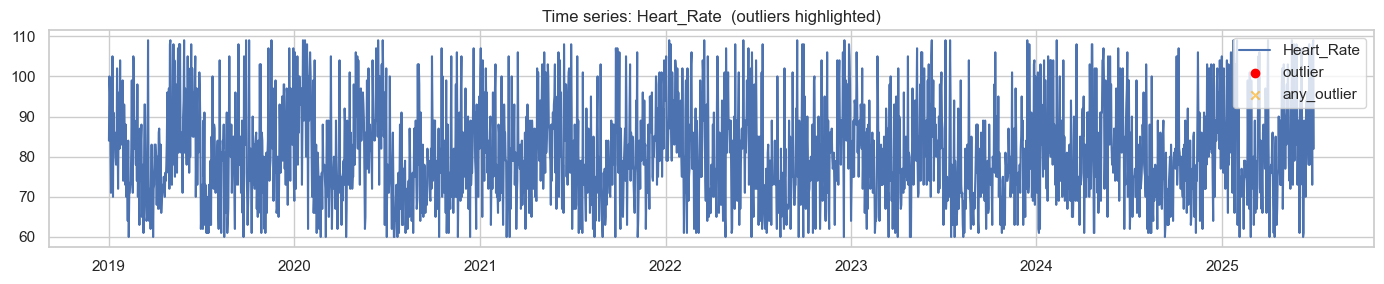

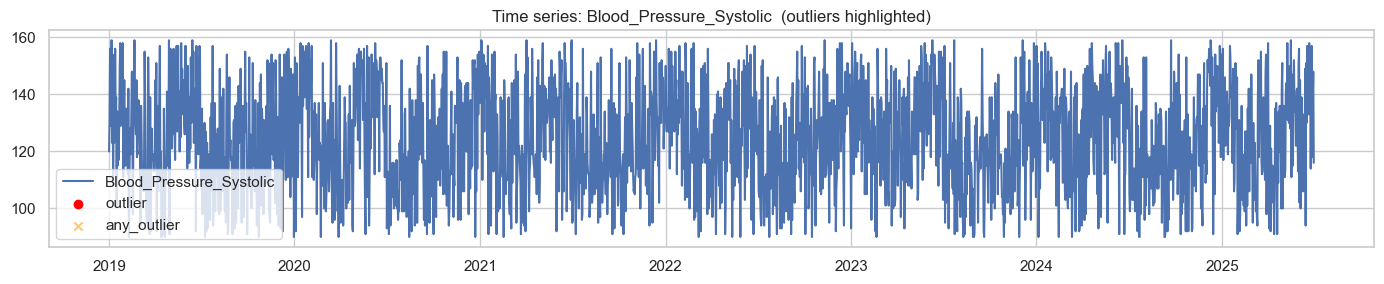

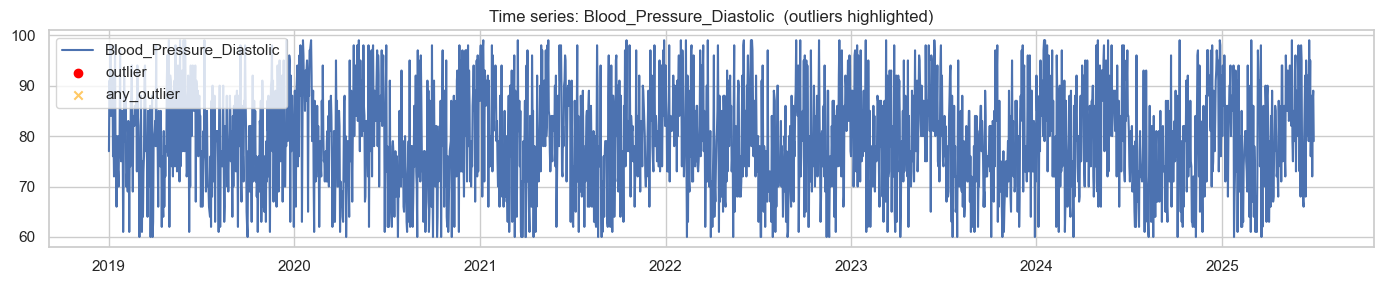

In [52]:
# Plot numeric columns with outliers highlighted
import matplotlib.pyplot as plt

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
# Remove helper flags from plotting
numeric_cols = [c for c in numeric_cols if not c.startswith("is_outlier_")]

# Choose which columns to plot — default: top 3 numeric cols by non-null count
cols_to_plot = numeric_cols[:3] if len(numeric_cols) else []
figsize = (14, 3 * max(1, len(cols_to_plot)))

for i, col in enumerate(cols_to_plot, 1):
    plt.figure(figsize=(14, 3))
    plt.plot(df.index, df[col], label=col)
    # highlight outliers for this column (if per-col flag exists)
    flag_col = "is_outlier_" + col
    if flag_col in df.columns:
        out_idx = df.index[df[flag_col] == True]
        plt.scatter(out_idx, df.loc[out_idx, col], color='red', label='outlier', zorder=3)
    # also mark any rows flagged as any-outlier
    any_out_idx = df.index[df["is_outlier_any"] == True]
    plt.scatter(any_out_idx, df.loc[any_out_idx, col], marker='x', color='orange', alpha=0.6, label='any_outlier', zorder=2)
    plt.title(f"Time series: {col}  (outliers highlighted)")
    plt.legend()
    plt.tight_layout()
    plt.show()


In [54]:
# Context around each outlier (robust, pandas 2.x compatible)
import pandas as pd
from pandas import concat

context_window = 5  # number of periods before/after to show

# Ensure inferred_freq exists; fallback to median diff if not
if 'inferred_freq' in globals() and inferred_freq is not None:
    try:
        offset = pd.tseries.frequencies.to_offset(inferred_freq)
    except Exception:
        # if inferred_freq is an odd string, fallback
        diffs = df.index.to_series().diff().dropna()
        offset = diffs.median()
else:
    diffs = df.index.to_series().diff().dropna()
    if len(diffs) == 0:
        raise ValueError("Not enough timestamps to determine frequency for context window.")
    offset = diffs.median()

for ts in outlier_rows.index:
    start = ts - offset * context_window
    end   = ts + offset * context_window
    print(f"\n=== Context around {ts} ({start} → {end}) ===")
    slice_df = df.loc[start:end]
    if slice_df.empty:
        print("No rows in this range (check inferred_freq or timestamp alignment).")
        continue

    # If slice small, show entire slice; otherwise show head+tail concatenated
    if len(slice_df) <= 10:
        display(slice_df)
    else:
        display(concat([slice_df.head(2), slice_df.tail(2)]))


In [55]:
# Inspect DataFrame dtypes and index class
print("Index type:", type(df.index))
print("Index dtype:", getattr(df.index, "dtype", None))
print("\nColumn dtypes summary:")
print(df.dtypes.value_counts())

# Show columns with pandas Period / Interval / Extension dtypes
from pandas.api import types as pdtypes

period_cols = [c for c in df.columns if pdtypes.is_period_dtype(df[c].dtype)]
interval_cols = [c for c in df.columns if pdtypes.is_interval_dtype(df[c].dtype)]
extension_cols = [c for c in df.columns if pdtypes.is_extension_array_dtype(df[c].dtype)]

print(f"\nPeriod dtype columns: {period_cols}")
print(f"Interval dtype columns: {interval_cols}")
print(f"Other extension dtype columns: { [c for c in extension_cols if c not in period_cols+interval_cols] }")


Index type: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>
Index dtype: datetime64[ns]

Column dtypes summary:
bool      11
int64      9
object     3
Name: count, dtype: int64

Period dtype columns: []
Interval dtype columns: []
Other extension dtype columns: []


C:\Users\ASUS\AppData\Local\Temp\ipykernel_7332\3806357691.py:10: DeprecationWarning: is_period_dtype is deprecated and will be removed in a future version. Use `isinstance(dtype, pd.PeriodDtype)` instead
  period_cols = [c for c in df.columns if pdtypes.is_period_dtype(df[c].dtype)]
C:\Users\ASUS\AppData\Local\Temp\ipykernel_7332\3806357691.py:11: DeprecationWarning: is_interval_dtype is deprecated and will be removed in a future version. Use `isinstance(dtype, pd.IntervalDtype)` instead
  interval_cols = [c for c in df.columns if pdtypes.is_interval_dtype(df[c].dtype)]


In [56]:
import warnings, traceback

parquet_path = "./data/cleaned_snapshot_with_outlier_flags.parquet"
csv_path = "./data/cleaned_snapshot_with_outlier_flags.csv"
pkl_path = "./data/cleaned_snapshot_with_outlier_flags.pkl"

try:
    df.to_parquet(parquet_path, index=True)  # try default (pyarrow)
    print("Saved parquet (pyarrow) ->", parquet_path)
except Exception as e1:
    print("pyarrow save failed:", type(e1).__name__, e1)
    traceback.print_exc()
    try:
        df.to_parquet(parquet_path, engine="fastparquet", index=True)
        print("Saved parquet (fastparquet) ->", parquet_path)
    except Exception as e2:
        print("fastparquet save also failed:", type(e2).__name__, e2)
        traceback.print_exc()
        print("Falling back to CSV and pickle...")
        df.to_csv(csv_path, index=True)
        df.to_pickle(pkl_path)
        print("Saved CSV ->", csv_path)
        print("Saved pickle ->", pkl_path)


Saved parquet (pyarrow) -> ./data/cleaned_snapshot_with_outlier_flags.parquet


In [15]:
%pip install -U fastparquet


Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\Users\ASUS\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.


In [57]:
from pandas.api import types as pdtypes

def force_primitive_conversion(df_in):
    df_work = df_in.copy()
    # move index into a column to avoid index-related extension issues
    try:
        df_work = df_work.reset_index()
    except Exception:
        pass
    for c in df_work.columns:
        ser = df_work[c]
        if pdtypes.is_datetime64_any_dtype(ser.dtype) or pdtypes.is_numeric_dtype(ser.dtype):
            continue
        # otherwise convert to plain python objects (None for NaN)
        df_work[c] = ser.astype(object).where(ser.notna(), None)
    return df_work

df_safe = force_primitive_conversion(df)

# 4.A Try pandas .to_parquet (may still import pandas' extension types)
try:
    df_safe.to_parquet("./data/cleaned_snapshot_with_outlier_flags_primitive.parquet", index=False)
    print("Saved primitive parquet -> ./data/cleaned_snapshot_with_outlier_flags_primitive.parquet")
except Exception as e:
    print("pandas.to_parquet still failed:", type(e).__name__, e)

    # 4.B Try writing with pyarrow directly (less pandas-internal hooks)
    try:
        import pyarrow as pa
        import pyarrow.parquet as pq
        table = pa.Table.from_pandas(df_safe, preserve_index=False)
        pq.write_table(table, "./data/cleaned_snapshot_with_outlier_flags_pyarrow.parquet")
        print("Saved parquet via pyarrow -> ./data/cleaned_snapshot_with_outlier_flags_pyarrow.parquet")
    except Exception as e2:
        print("pyarrow write also failed:", type(e2).__name__, e2)
        # final fallback: CSV & pickle (already created)
        df_safe.to_csv("./data/cleaned_snapshot_with_outlier_flags_fallback.csv", index=False)
        df_safe.to_pickle("./data/cleaned_snapshot_with_outlier_flags_fallback.pkl")
        print("Saved fallback CSV & pickle.")


Saved primitive parquet -> ./data/cleaned_snapshot_with_outlier_flags_primitive.parquet


In [17]:
%pip install statsmodels


Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\Users\ASUS\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.


In [58]:
# ============================================================
# CLEAN DATASET — keep only original columns
# ============================================================

# List all current columns
print("Total columns before cleanup:", len(df.columns))

# Define columns to remove (any outlier flags or helper columns)
cols_to_drop = [c for c in df.columns if "outlier" in c.lower() or "in_long_gap" in c.lower() or c.endswith("_num")]

# Drop duplicates in case
cols_to_drop = list(set(cols_to_drop))

# Drop those columns safely
df = df.drop(columns=cols_to_drop, errors="ignore")

print(f"Dropped {len(cols_to_drop)} temporary/helper columns.")
print("Remaining columns:", len(df.columns))
print("Sample of remaining columns:")
print(df.columns.tolist())


Total columns before cleanup: 23
Dropped 11 temporary/helper columns.
Remaining columns: 12
Sample of remaining columns:
['Heart_Rate', 'Blood_Pressure_Systolic', 'Blood_Pressure_Diastolic', 'Respiration_Rate', 'Sleep_Duration', 'Activity_Levels', 'Mood', 'Cognitive_Load', 'Study_Hours', 'Academic_Stressors', 'Stress_Level', 'Mental_Health_Status']


In [59]:
print(df["Stress_Level"].head())

timestamp
2019-01-01    Medium
2019-01-02      High
2019-01-03      High
2019-01-04      High
2019-01-05    Medium
Freq: D, Name: Stress_Level, dtype: object


In [60]:
# =================== Cell A: Imports & config ===================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.api import types as pdtypes

sns.set(style="whitegrid", context="notebook")
# If you need statsmodels functions, import inside the cells that use them (so install can be handled separately)

# Set your target column names (adjust if your dataset uses different names)
PRIMARY_TARGET = "Mental_Health_Status"   # categorical
SECONDARY_TARGET = "Stress_Level"         # numeric / ordinal

# Quick existence checks
missing = [c for c in (PRIMARY_TARGET, SECONDARY_TARGET) if c not in df.columns]
if missing:
    raise KeyError(f"Missing expected target column(s) in df: {missing}")

# Ensure index is datetime
if not isinstance(df.index, pd.DatetimeIndex):
    # Try to convert if there's a Timestamp-like column named 'Timestamp' or similar
    if "Timestamp" in df.columns:
        df["Timestamp"] = pd.to_datetime(df["Timestamp"], errors="coerce")
        df = df.dropna(subset=["Timestamp"]).set_index("Timestamp")
        df.index.name = "timestamp"
    else:
        raise ValueError("df.index is not a DatetimeIndex. Ensure your timestamp column is parsed and set as index.")

print("Primary target (categorical):", PRIMARY_TARGET)
print("Secondary target (numeric):", SECONDARY_TARGET)
print("Data time span:", df.index.min(), "->", df.index.max())
print("Shape:", df.shape)


Primary target (categorical): Mental_Health_Status
Secondary target (numeric): Stress_Level
Data time span: 2019-01-01 00:00:00 -> 2025-06-30 00:00:00
Shape: (2373, 12)


In [61]:
# =================== Cell B: Target summaries ===================
print("Value counts for primary (categorical) target:")
display(df[PRIMARY_TARGET].value_counts(dropna=False))

print("\nBasic stats for secondary (numeric/ordinal) target:")
display(df[SECONDARY_TARGET].describe())

# If secondary target is not numeric, try to coerce to numeric for numeric analyses
if not pdtypes.is_numeric_dtype(df[SECONDARY_TARGET].dtype):
    try:
        df[SECONDARY_TARGET + "_num"] = pd.to_numeric(df[SECONDARY_TARGET], errors="coerce")
        print(f"\nConverted {SECONDARY_TARGET} -> {SECONDARY_TARGET+'_num'} for numeric analyses (NaNs for non-convertible).")
    except Exception as e:
        print("Could not convert secondary target to numeric:", e)


Value counts for primary (categorical) target:


Mental_Health_Status
Normal             600
Mild Stress        565
Moderate Stress    502
Severe Stress      392
Anxiety            314
Name: count, dtype: int64


Basic stats for secondary (numeric/ordinal) target:


count       2373
unique         3
top       Medium
freq         829
Name: Stress_Level, dtype: object


Converted Stress_Level -> Stress_Level_num for numeric analyses (NaNs for non-convertible).


In [62]:
df["Stress_Level"].value_counts(dropna=False)


Stress_Level
Medium    829
Low       787
High      757
Name: count, dtype: int64

In [63]:
# ============================================================
# Convert Stress_Level categorical labels to ordered numeric codes
# ============================================================

stress_mapping = {
    "Low": 1,
    "Medium": 2,
    "High": 3,
}

# Apply mapping
df["Stress_Level_num"] = df["Stress_Level"].map(stress_mapping)

# Show result summary
print(df["Stress_Level_num"].describe())
print("\nUnique Stress_Level values:", df["Stress_Level"].unique())


count    2373.000000
mean        1.987358
std         0.806702
min         1.000000
25%         1.000000
50%         2.000000
75%         3.000000
max         3.000000
Name: Stress_Level_num, dtype: float64

Unique Stress_Level values: ['Medium' 'High' 'Low']


In [65]:
# =================== Updated Cell B section for Stress_Level ===================

# If secondary target is not numeric, attempt ordinal mapping
if not pdtypes.is_numeric_dtype(df[SECONDARY_TARGET].dtype):
    unique_vals = df[SECONDARY_TARGET].dropna().unique()
    print("Detected non-numeric Stress_Level values:", unique_vals)

    # Define ordinal mapping (adjust according to your dataset values)
    stress_mapping = {
    "Low": 1,
    "Medium": 2,
    "High": 3,
}

    df[SECONDARY_TARGET + "_num"] = df[SECONDARY_TARGET].map(stress_mapping)

    if df[SECONDARY_TARGET + "_num"].isnull().all():
        print("Warning: Mapping did not match your Stress_Level values. Check spelling or case (e.g., 'low' vs 'Low').")
    else:
        print(f"Converted {SECONDARY_TARGET} -> {SECONDARY_TARGET + '_num'} using ordinal mapping.")
        display(df[SECONDARY_TARGET + '_num'].describe())


Detected non-numeric Stress_Level values: ['Medium' 'High' 'Low']
Converted Stress_Level -> Stress_Level_num using ordinal mapping.


count    2373.000000
mean        1.987358
std         0.806702
min         1.000000
25%         1.000000
50%         2.000000
75%         3.000000
max         3.000000
Name: Stress_Level_num, dtype: float64

In [66]:
print(df["Stress_Level"].head())

timestamp
2019-01-01    Medium
2019-01-02      High
2019-01-03      High
2019-01-04      High
2019-01-05    Medium
Freq: D, Name: Stress_Level, dtype: object


In [26]:
# # Daily counts per class (correct way)
# daily_counts = df.groupby([pd.Grouper(freq="D"), PRIMARY_TARGET]).size().unstack(fill_value=0)
# plt.figure(figsize=(14,4))
# daily_counts.plot(kind="line", linewidth=1, ax=plt.gca())
# plt.title(f"Daily counts by {PRIMARY_TARGET}")
# plt.ylabel("Count")
# plt.xlabel("Date")
# plt.legend(title=PRIMARY_TARGET, bbox_to_anchor=(1.01,1))
# plt.tight_layout()
# plt.show()


In [27]:
# # Use the numeric column we created earlier
# if SECONDARY_TARGET + "_num" not in df.columns:
#     raise KeyError(f"{SECONDARY_TARGET + '_num'} not found — create it via mapping first.")

# sr = df[SECONDARY_TARGET + "_num"]
# # optionally resample to daily mean for smoother plot (use freq that suits your data)
# sr_daily = sr.resample("D").mean()

# plt.figure(figsize=(14,4))
# plt.plot(sr_daily.index, sr_daily.values, label=f"{SECONDARY_TARGET}_daily_mean", alpha=0.8)
# plt.plot(sr_daily.rolling(window=7, min_periods=1).mean(), linestyle="--", label="7-day rolling mean")
# plt.title(f"Daily mean of {SECONDARY_TARGET} (numeric)")
# plt.xlabel("Time")
# plt.ylabel(f"{SECONDARY_TARGET} (numeric)")
# plt.legend()
# plt.tight_layout()
# plt.show()


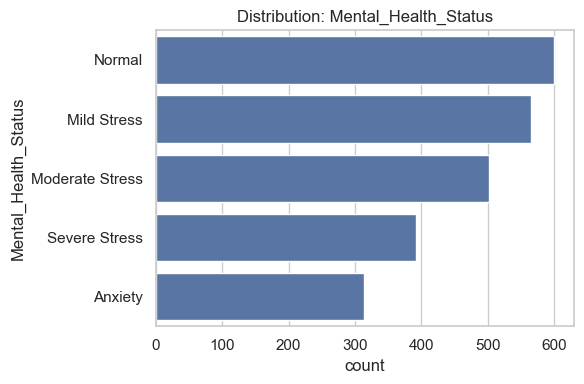

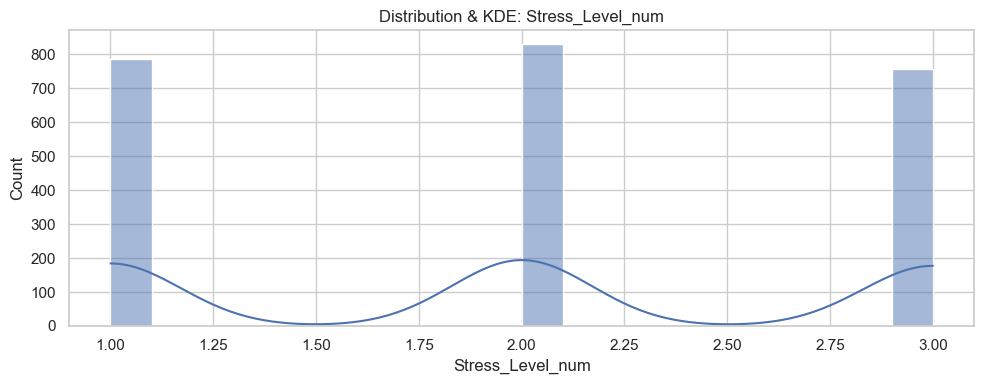

In [28]:
# Categorical distribution (bar)
plt.figure(figsize=(6,4))
order = df[PRIMARY_TARGET].value_counts().index
sns.countplot(y=PRIMARY_TARGET, data=df, order=order)
plt.title(f"Distribution: {PRIMARY_TARGET}")
plt.tight_layout()
plt.show()

# Numeric distribution for Stress_Level_num
plt.figure(figsize=(10,4))
sns.histplot(df[SECONDARY_TARGET + "_num"].dropna(), kde=True, bins=20)
plt.title(f"Distribution & KDE: {SECONDARY_TARGET}_num")
plt.tight_layout()
plt.show()


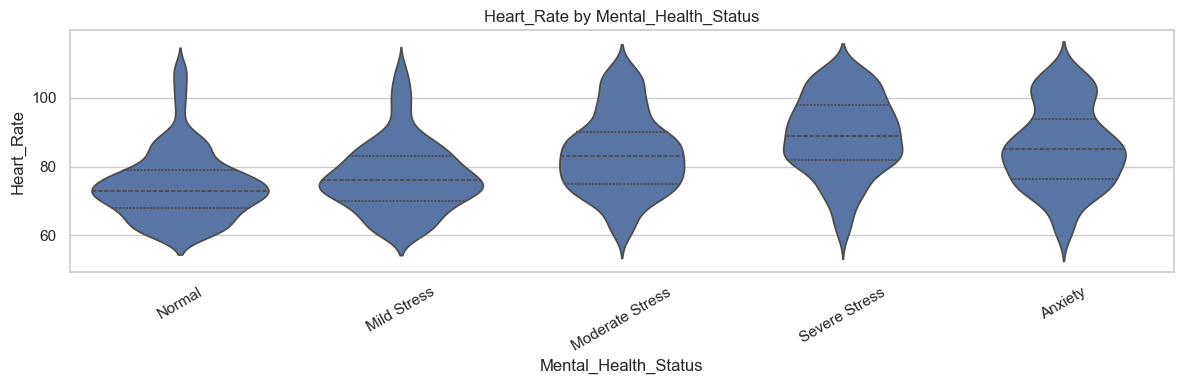

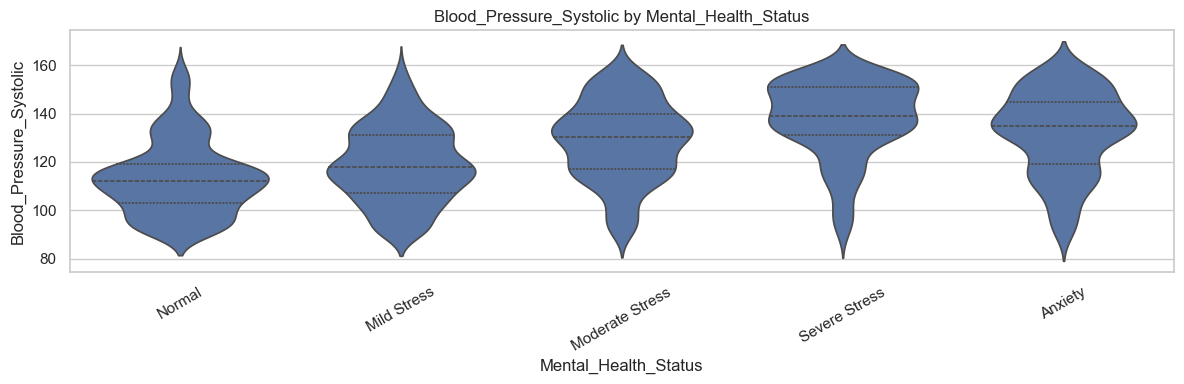

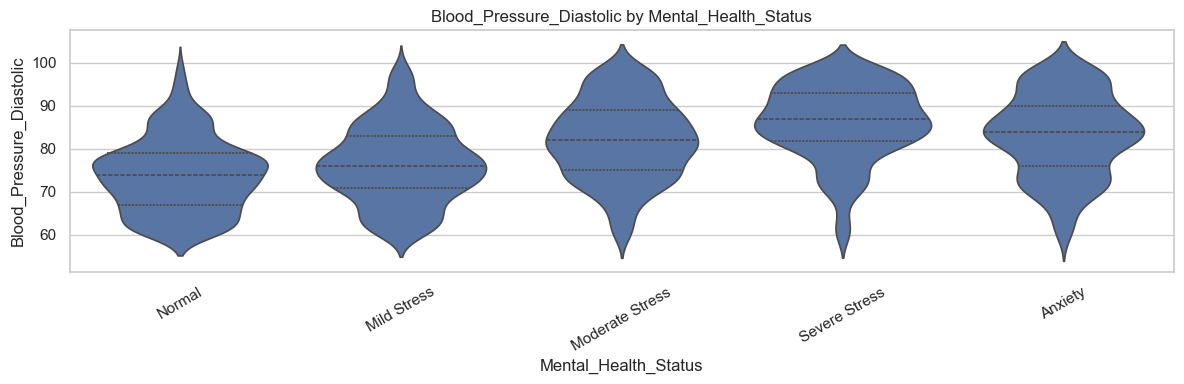

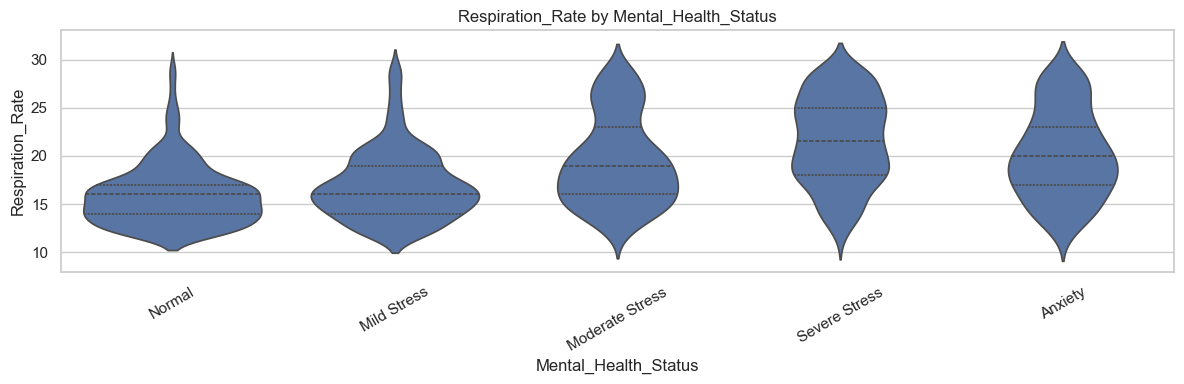

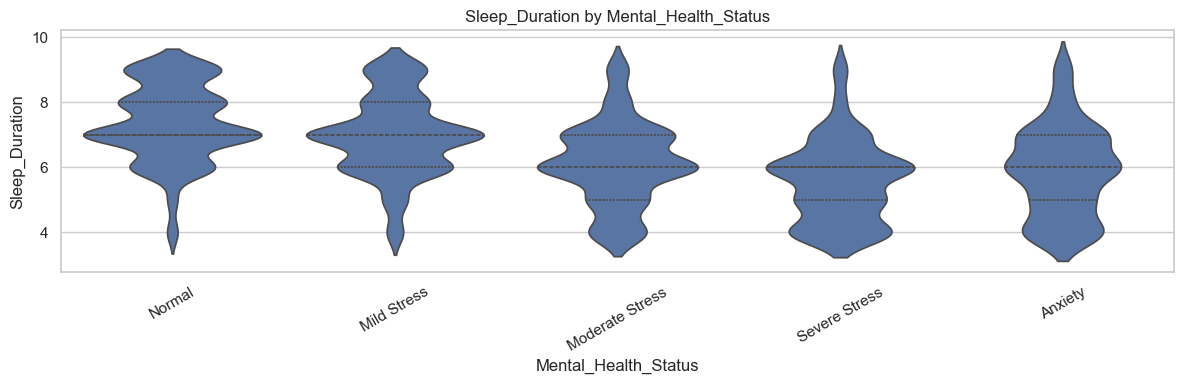

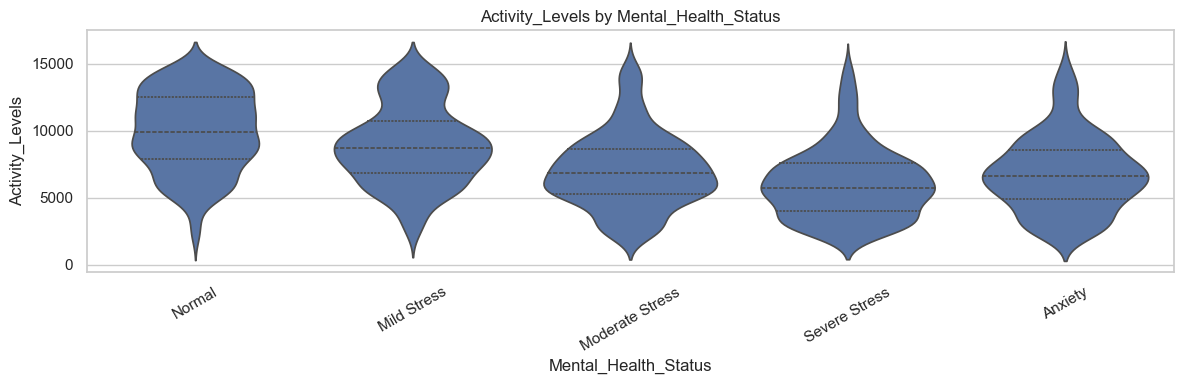

In [29]:
# Choose some numeric features to compare
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
# Exclude helper numeric cols if present
numeric_cols = [c for c in numeric_cols if not c.endswith("_num") or c == SECONDARY_TARGET + "_num"]
# pick a few for plotting
cols_to_compare = numeric_cols[:6]

for col in cols_to_compare:
    plt.figure(figsize=(12,4))
    sns.violinplot(x=PRIMARY_TARGET, y=col, data=df, order=order, inner="quartile")
    plt.title(f"{col} by {PRIMARY_TARGET}")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()


In [30]:
# def plot_targets_overview(df, primary, secondary_num, resample_freq="D", rolling_window=7):
#     # categorical daily counts
#     daily_counts = df.groupby([pd.Grouper(freq=resample_freq), primary]).size().unstack(fill_value=0)
#     ax = daily_counts.plot(figsize=(14,3), legend=False)
#     ax.set_title(f"Daily counts by {primary}")
#     ax.set_ylabel("Count")
#     plt.show()

#     # numeric resampled
#     sr = df[secondary_num].resample(resample_freq).mean()
#     plt.figure(figsize=(14,3))
#     plt.plot(sr.index, sr.values, label=secondary_num)
#     plt.plot(sr.rolling(window=rolling_window, min_periods=1).mean(), linestyle="--", label=f"{rolling_window}-period rolling mean")
#     plt.title(f"{secondary_num} over time (resampled {resample_freq})")
#     plt.legend()
#     plt.show()

# # call it
# plot_targets_overview(df, PRIMARY_TARGET, SECONDARY_TARGET + "_num", resample_freq="D", rolling_window=7)


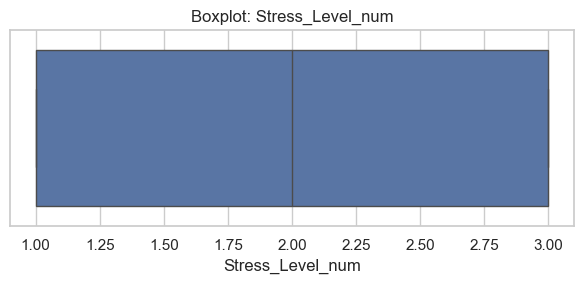

In [31]:
# =================== Cell D: Distributions (fixed) ===================

# Categorical distribution (bar)


# Numeric distribution — use numeric mapped column
num_col = SECONDARY_TARGET + "_num"
if num_col not in df.columns:
    raise KeyError(f"{num_col} not found; create it via mapping first.")



# Boxplot for numeric target (show outliers)
plt.figure(figsize=(6,3))
sns.boxplot(x=df[num_col].dropna())
plt.title(f"Boxplot: {num_col}")
plt.tight_layout()
plt.show()


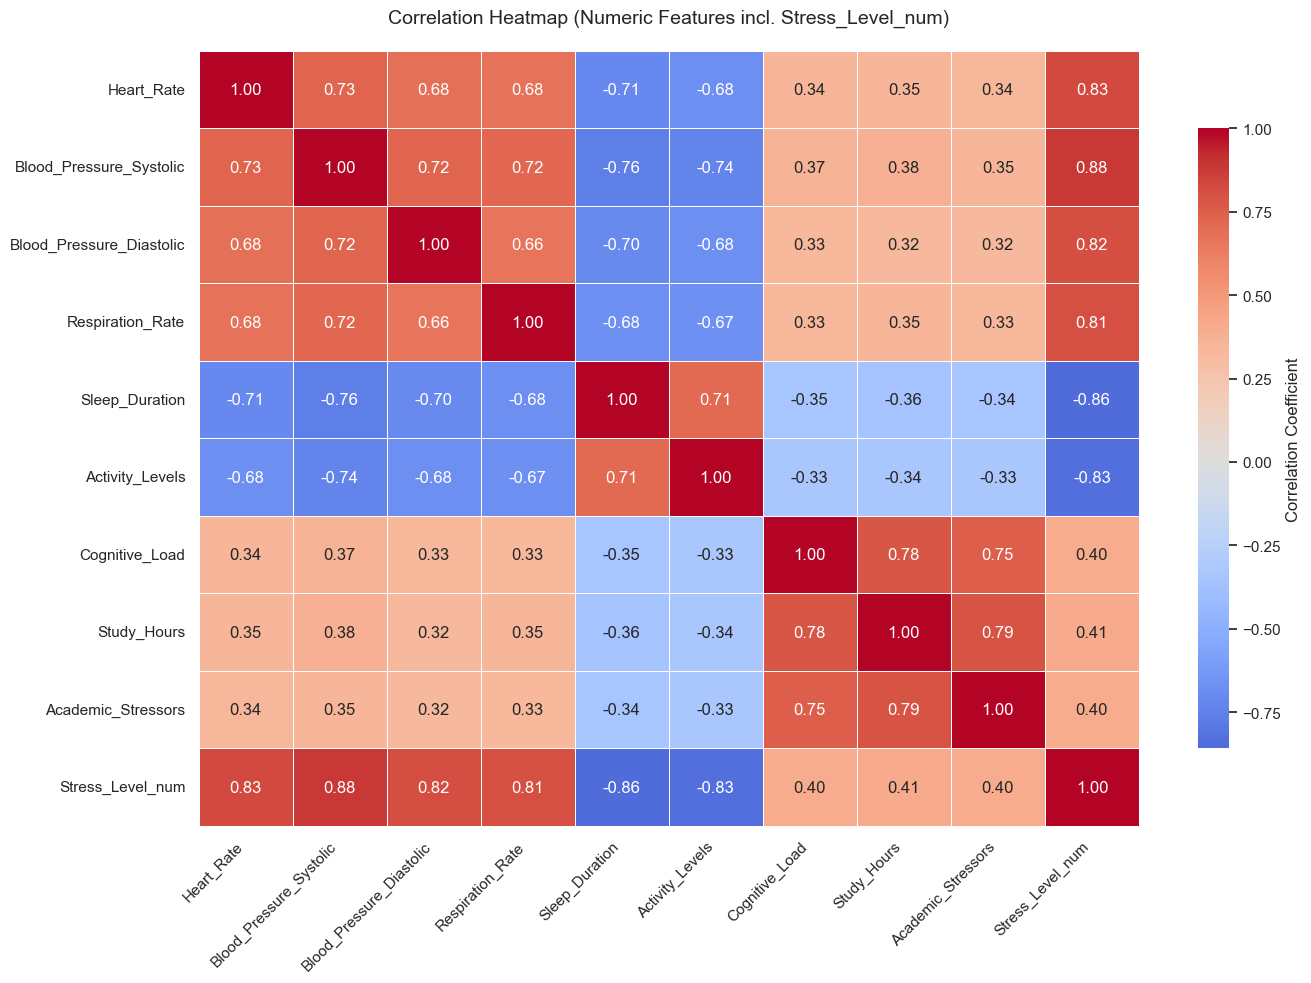

Top features correlated with Stress_Level_num:


Blood_Pressure_Systolic     0.882296
Sleep_Duration              0.857914
Activity_Levels             0.831875
Heart_Rate                  0.827609
Blood_Pressure_Diastolic    0.818225
Respiration_Rate            0.809661
Study_Hours                 0.408081
Cognitive_Load              0.400911
Academic_Stressors          0.398211
Name: Stress_Level_num, dtype: float64

In [32]:
# ============================================================
# Improved Correlation Heatmap with annotations and better scaling
# ============================================================

# Recalculate correlation matrix
num_df = df.select_dtypes(include=[np.number]).copy()
stress_num = SECONDARY_TARGET + "_num"
if stress_num in df.columns:
    num_df[stress_num] = df[stress_num]

corr = num_df.corr()

# Plot
plt.figure(figsize=(14,10))  # Larger figure
sns.heatmap(
    corr,
    cmap="coolwarm",          # Better gradient visibility
    center=0,
    annot=True,               # Show numeric correlation values
    fmt=".2f",                # 2 decimal places
    linewidths=0.5,           # Fine grid lines
    cbar_kws={"shrink": 0.8, "label": "Correlation Coefficient"}
)
plt.title("Correlation Heatmap (Numeric Features incl. Stress_Level_num)", fontsize=14, pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Display strongest correlations (absolute)
top_corr = corr[stress_num].abs().sort_values(ascending=False).drop(stress_num)
print("Top features correlated with Stress_Level_num:")
display(top_corr.head(10))


In [68]:
# ============================================================
# Encode Mental_Health_Status to ordinal numeric values
# ============================================================

# Define mapping (ordered roughly by severity)
mental_map = {
    "Normal": 0,
    "Mild Stress": 1,
    "Moderate Stress": 2,
    "Severe Stress": 3,
    "Anxiety": 4,
    "Depression": 5
}

df["Mental_Health_Status_num"] = df["Mental_Health_Status"].map(mental_map)

# Verify encoding
print(df["Mental_Health_Status_num"].value_counts().sort_index())


Mental_Health_Status_num
0    600
1    565
2    502
3    392
4    314
Name: count, dtype: int64


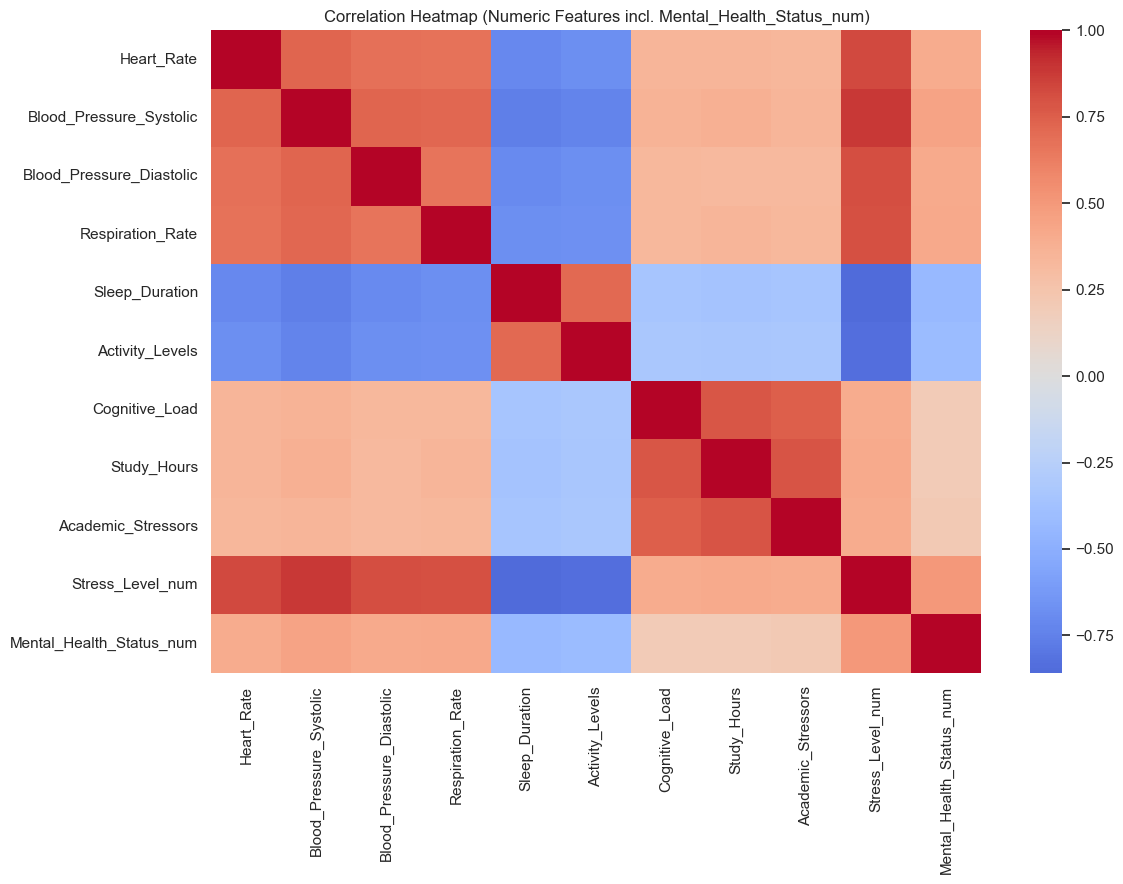


Top correlated features with Mental_Health_Status:


Stress_Level_num            0.504851
Blood_Pressure_Systolic     0.444769
Sleep_Duration              0.436695
Activity_Levels             0.417474
Respiration_Rate            0.415888
Blood_Pressure_Diastolic    0.412059
Heart_Rate                  0.401415
Academic_Stressors          0.210334
Cognitive_Load              0.200554
Study_Hours                 0.198198
Name: Mental_Health_Status_num, dtype: float64

In [69]:
# ============================================================
# Correlation with Mental_Health_Status_num
# ============================================================

num_df = df.select_dtypes(include=[np.number]).copy()

if "Mental_Health_Status_num" in num_df.columns:
    corr = num_df.corr()
    top_corr_mental = corr["Mental_Health_Status_num"].abs().sort_values(ascending=False).drop("Mental_Health_Status_num")
    
    plt.figure(figsize=(12,9))
    sns.heatmap(corr, cmap="coolwarm", center=0, annot=False)
    plt.title("Correlation Heatmap (Numeric Features incl. Mental_Health_Status_num)")
    plt.tight_layout()
    plt.show()

    print("\nTop correlated features with Mental_Health_Status:")
    display(top_corr_mental.head(10))
else:
    print("Mental_Health_Status_num column not found. Please encode first.")


<Figure size 1200x400 with 0 Axes>

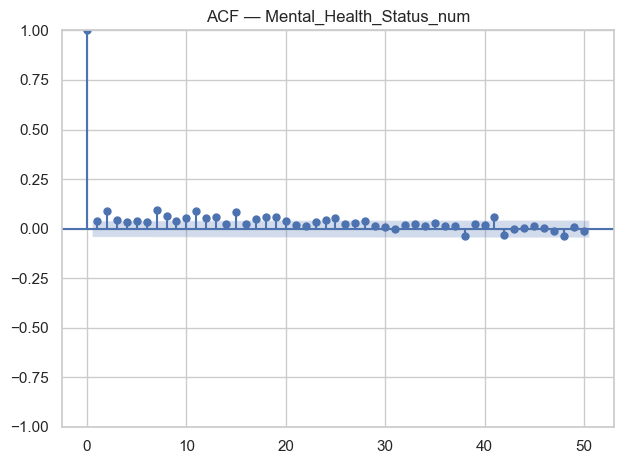

<Figure size 1200x400 with 0 Axes>

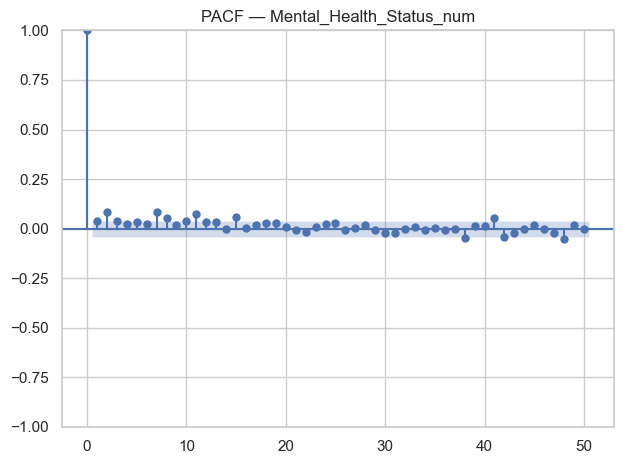

In [35]:
# ============================================================
# ACF & PACF for Mental_Health_Status_num
# ============================================================
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

series = df["Mental_Health_Status_num"].dropna()

plt.figure(figsize=(12,4))
plot_acf(series, lags=50, alpha=0.05)
plt.title("ACF — Mental_Health_Status_num")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,4))
plot_pacf(series, lags=50, alpha=0.05, method='ywm')
plt.title("PACF — Mental_Health_Status_num")
plt.tight_layout()
plt.show()


<Figure size 1200x400 with 0 Axes>

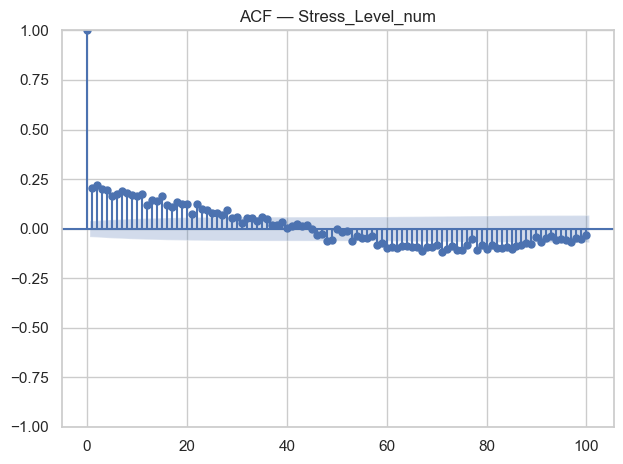

<Figure size 1200x400 with 0 Axes>

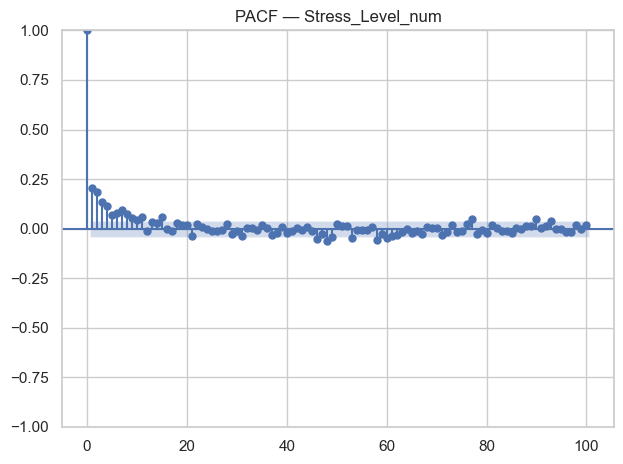

In [36]:
# =================== Cell G: ACF & PACF for Stress_Level_num (fixed) ===================
try:
    from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
    series = df[stress_num].dropna()
    if len(series) < 10:
        print("Not enough observations for ACF/PACF.")
    else:
        nlags = min(100, max(10, int(len(series)//10)))
        plt.figure(figsize=(12,4))
        plot_acf(series, lags=nlags, alpha=0.05)
        plt.title(f"ACF — {stress_num}")
        plt.tight_layout()
        plt.show()

        plt.figure(figsize=(12,4))
        plot_pacf(series, lags=nlags, alpha=0.05, method='ywm')
        plt.title(f"PACF — {stress_num}")
        plt.tight_layout()
        plt.show()
except Exception as e:
    print("statsmodels is required for ACF/PACF. Install with `pip install statsmodels` and restart kernel. Error:", e)


In [37]:
# ============================================================
# Stationarity tests for Mental_Health_Status_num
# ============================================================
from statsmodels.tsa.stattools import adfuller, kpss

series = df["Mental_Health_Status_num"].dropna()

# Augmented Dickey-Fuller test
adf_result = adfuller(series, autolag='AIC')
print("ADF Test:")
print(f"  Test Statistic: {adf_result[0]:.4f}")
print(f"  p-value: {adf_result[1]:.4f}")
print(f"  Stationary: {'Yes' if adf_result[1] < 0.05 else 'No'}")

# KPSS test
try:
    kpss_result = kpss(series, regression='c', nlags='auto')
    print("\nKPSS Test:")
    print(f"  Test Statistic: {kpss_result[0]:.4f}")
    print(f"  p-value: {kpss_result[1]:.4f}")
    print(f"  Stationary: {'Yes' if kpss_result[1] > 0.05 else 'No'}")
except Exception as e:
    print("KPSS failed:", e)


ADF Test:
  Test Statistic: -8.6938
  p-value: 0.0000
  Stationary: Yes

KPSS Test:
  Test Statistic: 0.2417
  p-value: 0.1000
  Stationary: Yes


C:\Users\ASUS\AppData\Local\Temp\ipykernel_7332\1608745639.py:17: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(series, regression='c', nlags='auto')


In [38]:
# # Joint plot between Stress_Level and Mental_Health_Status
# plt.figure(figsize=(6,5))
# sns.scatterplot(x="Stress_Level_num", y="Mental_Health_Status_num", data=df, alpha=0.4)
# plt.title("Relationship: Stress_Level vs Mental_Health_Status")
# plt.tight_layout()
# plt.show()

# corr_value = df["Stress_Level_num"].corr(df["Mental_Health_Status_num"])
# print(f"Correlation between Stress_Level_num and Mental_Health_Status_num: {corr_value:.3f}")


Top features for cross-corr: ['Blood_Pressure_Systolic', 'Sleep_Duration', 'Activity_Levels', 'Heart_Rate']


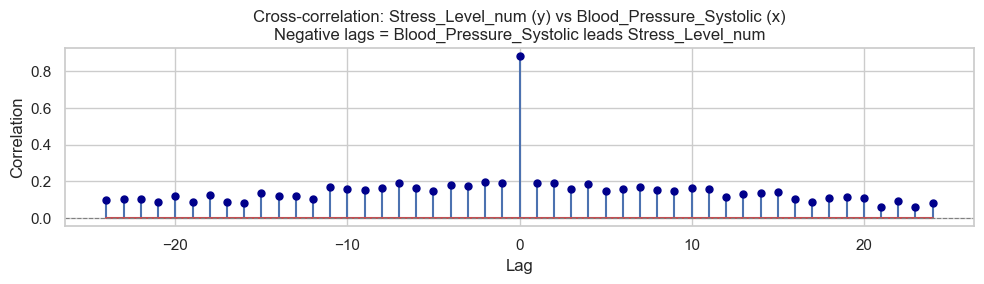

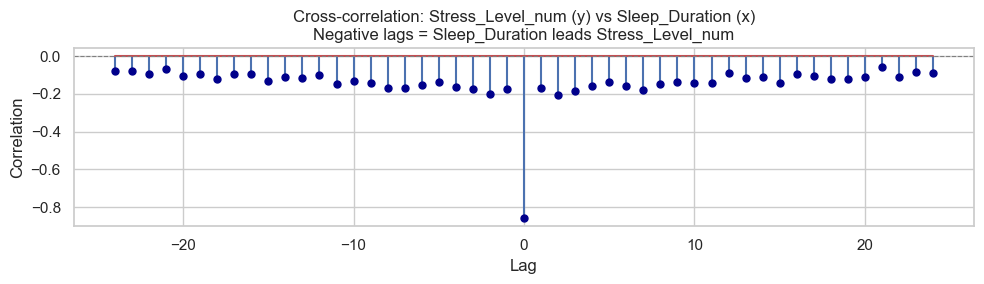

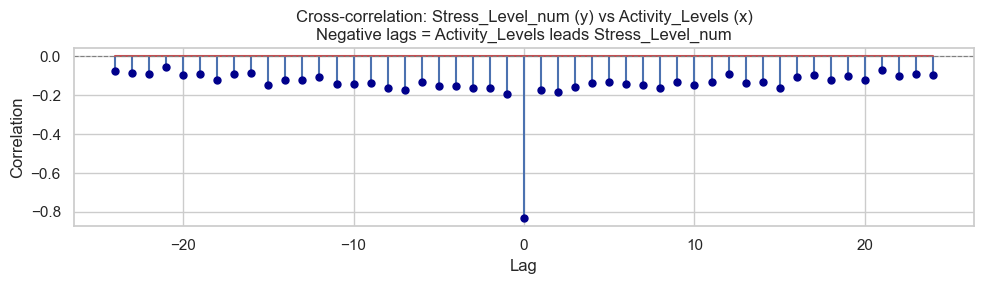

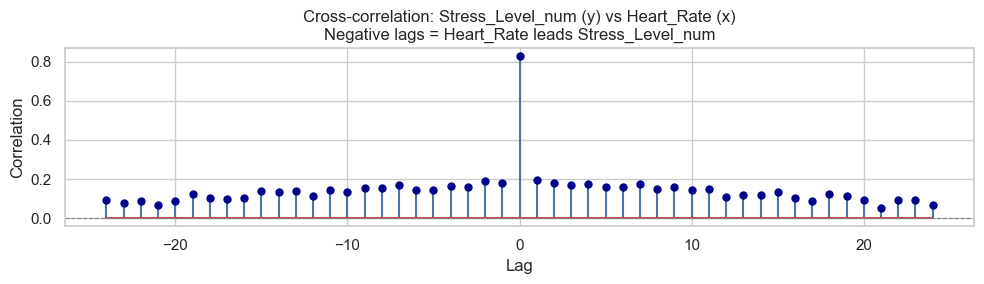

In [39]:
# =================== Cell H: Cross-correlation (lagged) with top features (fixed for Matplotlib ≥3.8) ===================

# Choose top features from correlation with stress_num (fallback to first numeric cols)
if stress_num in corr.columns:
    top_feats = corr[stress_num].abs().sort_values(ascending=False).drop(stress_num).index.tolist()[:4]
else:
    top_feats = [c for c in df.select_dtypes(include=[np.number]).columns.tolist() if c != stress_num][:4]

print("Top features for cross-corr:", top_feats)

# choose max_lag based on data frequency length; default 24 (adjust for daily vs hourly data)
max_lag = 24

for feat in top_feats:
    s_x = df[feat].dropna()
    s_y = df[stress_num].dropna()
    idx = s_x.index.intersection(s_y.index)
    s_x = s_x.loc[idx]
    s_y = s_y.loc[idx]

    if len(s_x) < max(2, max_lag * 2):
        print(f"Not enough overlap for cross-corr between {feat} and {stress_num}. Skipping.")
        continue

    # compute correlation at each lag
    ccs = [s_y.corr(s_x.shift(lag)) for lag in range(-max_lag, max_lag + 1)]
    lags = np.arange(-max_lag, max_lag + 1)

    # --- plotting ---
    plt.figure(figsize=(10, 3))
    markerline, stemlines, baseline = plt.stem(lags, ccs)  # compatible syntax
    plt.setp(stemlines, 'linewidth', 1.5)
    plt.setp(markerline, 'marker', 'o', 'color', 'darkblue', 'markersize', 5)
    plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
    plt.title(f"Cross-correlation: {stress_num} (y) vs {feat} (x)\nNegative lags = {feat} leads {stress_num}")
    plt.xlabel("Lag")
    plt.ylabel("Correlation")
    plt.tight_layout()
    plt.show()


C:\Users\ASUS\AppData\Local\Temp\ipykernel_7332\2044997135.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Stress_Level", y="Heart_Rate", data=df, order=["Low", "Medium", "High"], palette="coolwarm")
C:\Users\ASUS\AppData\Local\Temp\ipykernel_7332\2044997135.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Stress_Level", y="Blood_Pressure_Systolic", data=df, order=["Low", "Medium", "High"], palette="coolwarm")


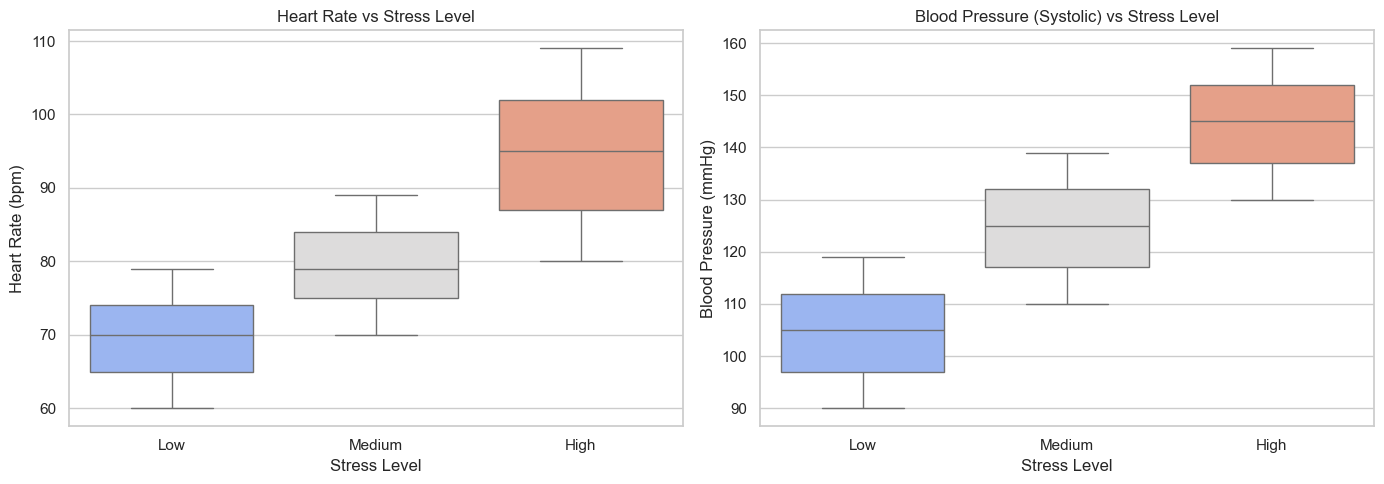

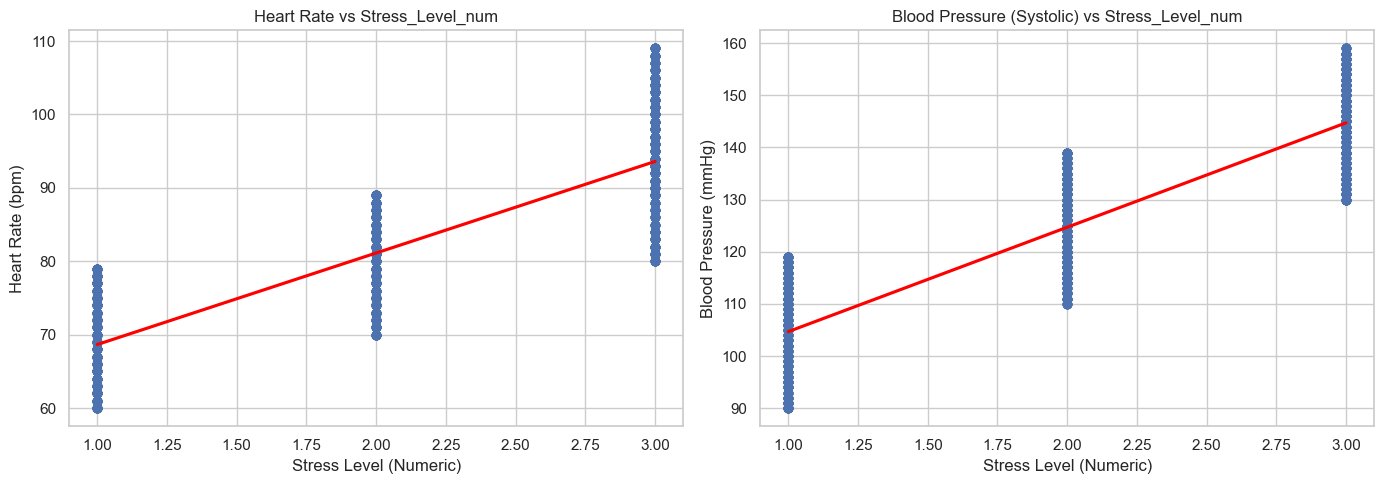

Correlation (Heart Rate vs Stress_Level_num): 0.828
Correlation (Systolic BP vs Stress_Level_num): 0.882


In [40]:
# ============================================================
# Relationship between Heart Rate, Blood Pressure vs Stress Level
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

# Ensure numeric stress column exists
stress_num = "Stress_Level_num"
if stress_num not in df.columns:
    raise KeyError("Please create 'Stress_Level_num' using the mapping before running this cell.")

# ------------------------------------------
# 1️⃣ BOX PLOTS — categorical comparison
# ------------------------------------------
plt.figure(figsize=(14,5))

plt.subplot(1, 2, 1)
sns.boxplot(x="Stress_Level", y="Heart_Rate", data=df, order=["Low", "Medium", "High"], palette="coolwarm")
plt.title("Heart Rate vs Stress Level")
plt.xlabel("Stress Level")
plt.ylabel("Heart Rate (bpm)")

plt.subplot(1, 2, 2)
sns.boxplot(x="Stress_Level", y="Blood_Pressure_Systolic", data=df, order=["Low", "Medium", "High"], palette="coolwarm")
plt.title("Blood Pressure (Systolic) vs Stress Level")
plt.xlabel("Stress Level")
plt.ylabel("Blood Pressure (mmHg)")

plt.tight_layout()
plt.show()

# ------------------------------------------
# 2️⃣ SCATTER + REGRESSION PLOTS — numeric correlation
# ------------------------------------------
plt.figure(figsize=(14,5))

plt.subplot(1, 2, 1)
sns.regplot(
    x=stress_num, y="Heart_Rate", data=df,
    scatter_kws={"alpha":0.4}, line_kws={"color":"red"}, ci=None
)
plt.title("Heart Rate vs Stress_Level_num")
plt.xlabel("Stress Level (Numeric)")
plt.ylabel("Heart Rate (bpm)")

plt.subplot(1, 2, 2)
sns.regplot(
    x=stress_num, y="Blood_Pressure_Systolic", data=df,
    scatter_kws={"alpha":0.4}, line_kws={"color":"red"}, ci=None
)
plt.title("Blood Pressure (Systolic) vs Stress_Level_num")
plt.xlabel("Stress Level (Numeric)")
plt.ylabel("Blood Pressure (mmHg)")

plt.tight_layout()
plt.show()

# ------------------------------------------
# 3️⃣ Print correlation coefficients
# ------------------------------------------
corr_hr = df["Heart_Rate"].corr(df[stress_num])
corr_bp = df["Blood_Pressure_Systolic"].corr(df[stress_num])
print(f"Correlation (Heart Rate vs Stress_Level_num): {corr_hr:.3f}")
print(f"Correlation (Systolic BP vs Stress_Level_num): {corr_bp:.3f}")


C:\Users\ASUS\AppData\Local\Temp\ipykernel_7332\1478488364.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Stress_Level", y=feat, data=df, order=["Low","Medium","High"], palette="coolwarm")


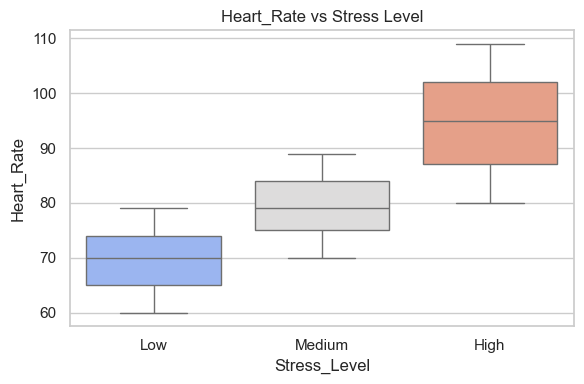

C:\Users\ASUS\AppData\Local\Temp\ipykernel_7332\1478488364.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Stress_Level", y=feat, data=df, order=["Low","Medium","High"], palette="coolwarm")


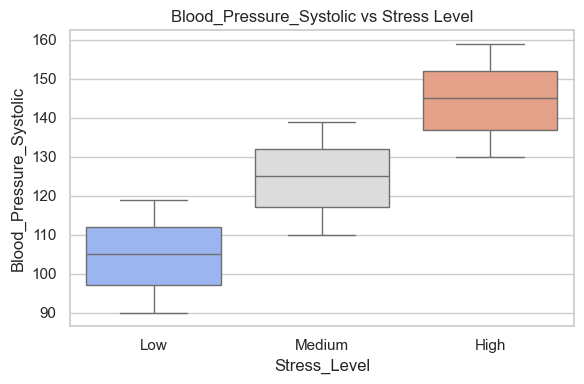

C:\Users\ASUS\AppData\Local\Temp\ipykernel_7332\1478488364.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Stress_Level", y=feat, data=df, order=["Low","Medium","High"], palette="coolwarm")


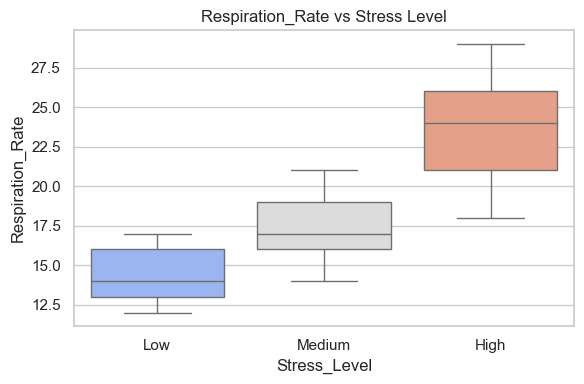

C:\Users\ASUS\AppData\Local\Temp\ipykernel_7332\1478488364.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Stress_Level", y=feat, data=df, order=["Low","Medium","High"], palette="coolwarm")


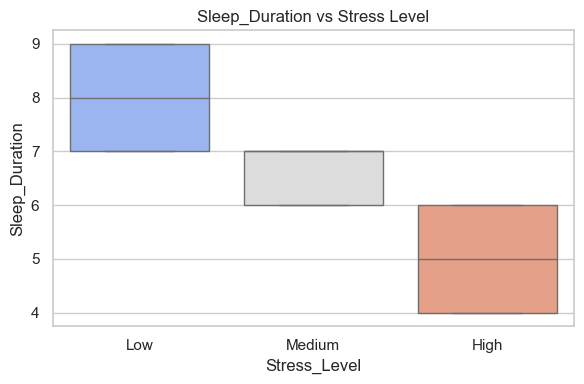

C:\Users\ASUS\AppData\Local\Temp\ipykernel_7332\1478488364.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Stress_Level", y=feat, data=df, order=["Low","Medium","High"], palette="coolwarm")


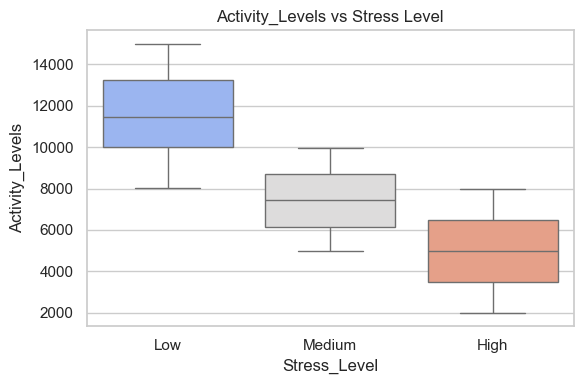

C:\Users\ASUS\AppData\Local\Temp\ipykernel_7332\1478488364.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Stress_Level", y=feat, data=df, order=["Low","Medium","High"], palette="coolwarm")


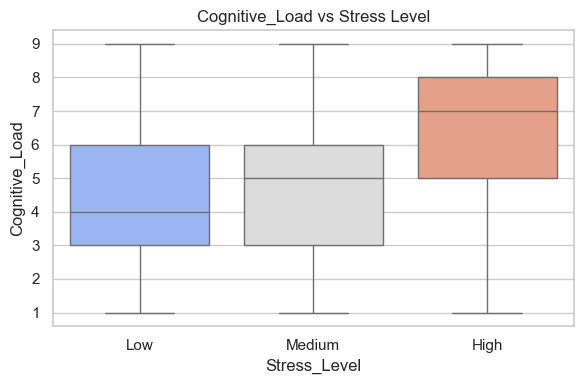

C:\Users\ASUS\AppData\Local\Temp\ipykernel_7332\1478488364.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Mental_Health_Status", y=feat, data=df[df["Mental_Health_Status"].isin(common_classes)],


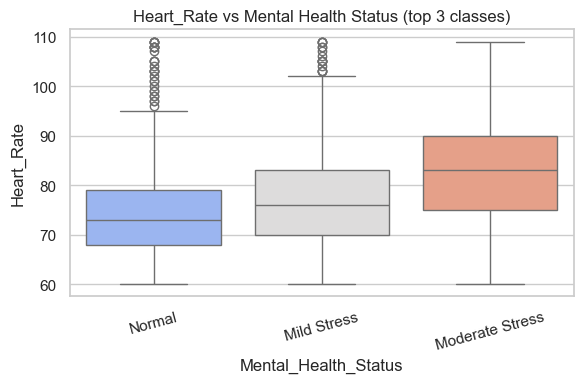

C:\Users\ASUS\AppData\Local\Temp\ipykernel_7332\1478488364.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Mental_Health_Status", y=feat, data=df[df["Mental_Health_Status"].isin(common_classes)],


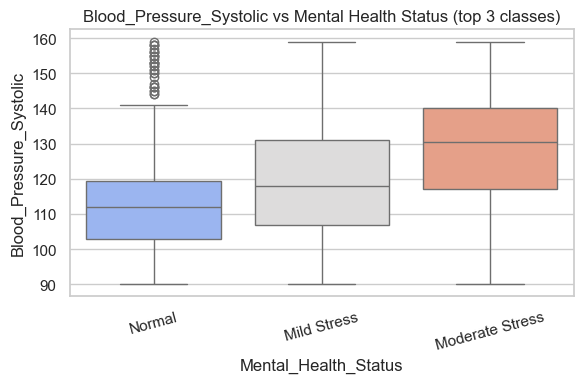

C:\Users\ASUS\AppData\Local\Temp\ipykernel_7332\1478488364.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Mental_Health_Status", y=feat, data=df[df["Mental_Health_Status"].isin(common_classes)],


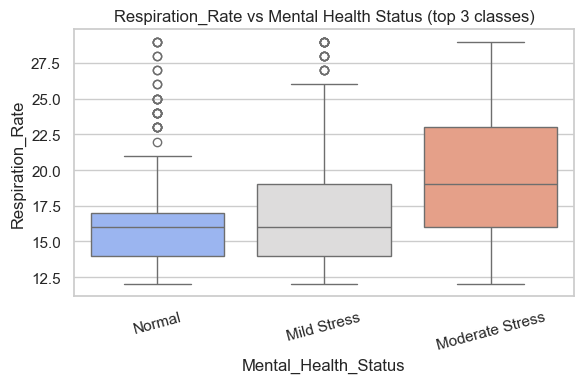

C:\Users\ASUS\AppData\Local\Temp\ipykernel_7332\1478488364.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Mental_Health_Status", y=feat, data=df[df["Mental_Health_Status"].isin(common_classes)],


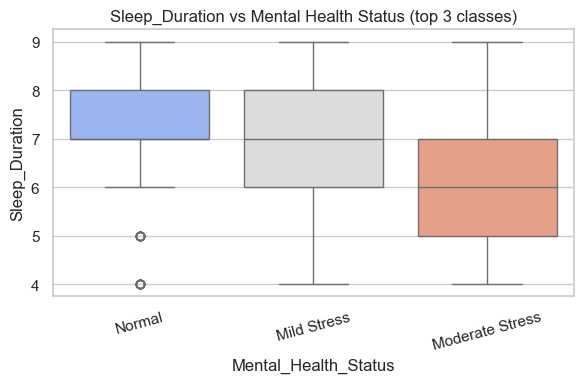

C:\Users\ASUS\AppData\Local\Temp\ipykernel_7332\1478488364.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Mental_Health_Status", y=feat, data=df[df["Mental_Health_Status"].isin(common_classes)],


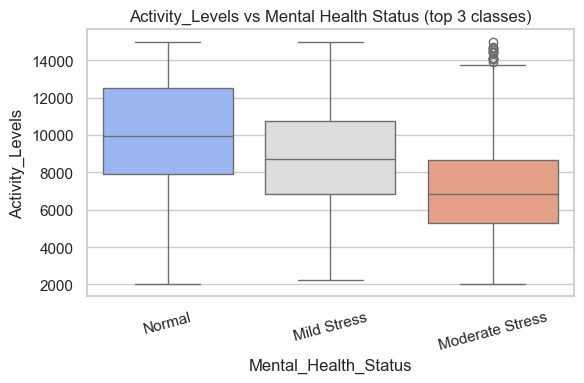

C:\Users\ASUS\AppData\Local\Temp\ipykernel_7332\1478488364.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Mental_Health_Status", y=feat, data=df[df["Mental_Health_Status"].isin(common_classes)],


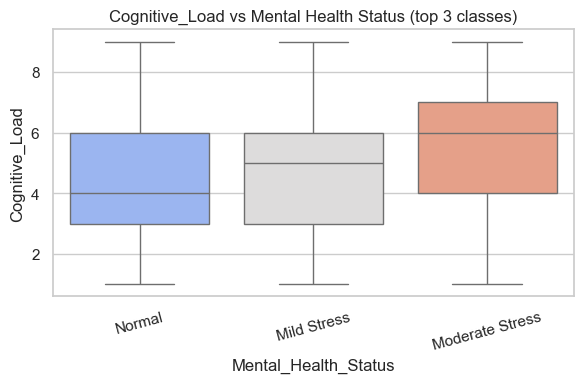

In [41]:
# Visual comparison: each feature vs Stress Level
features = ["Heart_Rate", "Blood_Pressure_Systolic", "Respiration_Rate",
            "Sleep_Duration", "Activity_Levels", "Cognitive_Load"]

for feat in features:
    plt.figure(figsize=(6,4))
    sns.boxplot(x="Stress_Level", y=feat, data=df, order=["Low","Medium","High"], palette="coolwarm")
    plt.title(f"{feat} vs Stress Level")
    plt.tight_layout()
    plt.show()

# Same for Mental_Health_Status (top 3 most common categories)
common_classes = df["Mental_Health_Status"].value_counts().index[:3]
for feat in features:
    plt.figure(figsize=(6,4))
    sns.boxplot(x="Mental_Health_Status", y=feat, data=df[df["Mental_Health_Status"].isin(common_classes)],
                order=common_classes, palette="coolwarm")
    plt.title(f"{feat} vs Mental Health Status (top 3 classes)")
    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.show()
